### FGA Training on Google Colab

Trains the **FGA (Fourier-Guided Attention)** upsampler on top of a frozen InvSR pipeline.

Companion docs in the repo: `TRAINING.md` (architecture) and `TRAINING_RUNBOOK.md` (phases + gates).
This notebook follows the runbook's phase numbering, so a failure here maps to a named phase there.

##### Before you start

1. **`Runtime -> Change runtime type -> T4 GPU`.** There is no CPU fallback: the scripts hardcode `.cuda()`.
2. Run the cells in order. Cells marked **GATE** must pass before you continue.
3. Everything you want to keep goes to Google Drive — Colab wipes local storage on disconnect.

##### What is and isn't cheap here

Training loads **only** the VAE (`AutoencoderKL`) — no U-Net, no noise predictor. One step is
`vae.decode(latent)` + loss, which is why this fits a free T4.

The expensive, fiddly part is *caching* (Phases 3-4), which does run the full frozen InvSR
backbone once per image. Cache once, keep it on Drive, then train as many variants as you like.

#### Phase -1 — Verify the GPU

In [1]:
!nvidia-smi
import torch
print("torch:", torch.__version__)
assert torch.cuda.is_available(), "No GPU. Runtime -> Change runtime type -> T4 GPU"
GPU = torch.cuda.get_device_name(0)
CAP = torch.cuda.get_device_capability(0)
print("gpu:", GPU, "| capability:", CAP)

# bf16 needs Ampere (sm_80+). T4 is Turing (sm_75) and has no native bf16.
BF16_OK = CAP[0] >= 8
AMP = "bf16" if BF16_OK else "fp16"
print(f"\nRecommended --amp: {AMP}")
if not BF16_OK:
    print("NOTE: Turing-class GPU. If the loss goes to nan, the runbook's 'switch to bf16'\n"
          "      remedy is NOT available here -- fall back to --amp off (float32, slower).")

Fri Sep  4 15:15:32 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 580.82.07              Driver Version: 580.82.07      CUDA Version: 13.0     |
+-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  Tesla T4                       Off |   00000000:00:04.0 Off |                    0 |
| N/A   40C    P8              9W /   70W |       0MiB /  15360MiB |      0%      Default |
|                                         |                        |                  N/A |
+-----------------------------------------+-----

#### Phase 0 — Clone and unblock the codebase

Two defects prevent training from starting. `master` on GitHub does not have the fixes yet
(they are uncommitted locally), so this cell applies them idempotently.

In [2]:
import os, subprocess

REPO_URL = "https://github.com/maylaniakba77/IFGA-SR.git"
REPO     = "/content/IFGA-SR"

if not os.path.exists(f"{REPO}/.git"):
    r = subprocess.run(["git", "clone", REPO_URL, REPO])
    assert r.returncode == 0, f"git clone failed ({r.returncode})"
else:
    print("repo already cloned")

os.chdir(REPO)
print("cwd:", os.getcwd())

# 0b — make the packages importable
for f in ("fga/__init__.py", "fga/archs/__init__.py", "fga_integration/__init__.py"):
    open(f, "a").close()
print("0b: __init__.py files present")

# 0a — patch_decoder.py calls FGAUpsample2D without importing it
IMPORT_LINE = "from fga_integration.fga_upsampler import FGAUpsample2D"
p = "fga_integration/patch_decoder.py"
src = open(p).read()
if IMPORT_LINE not in src:
    open(p, "w").write(IMPORT_LINE + "\n\n" + src)
    print("0a: import added")
else:
    print("0a: import already present")

cwd: /content/IFGA-SR
0b: __init__.py files present
0a: import already present


#### Phase 1 — Install

**Do not** run the README's pinned `torch==2.4.0 --index-url .../cu121` install. Colab already
ships a CUDA torch; replacing it costs ~5 minutes and routinely breaks the preinstalled stack.

What *is* mandatory: this repo's `setup.py` is **diffusers' own**, because the repo vendors a
patched diffusers under `src/`. It supplies `StableDiffusionInvEnhancePipeline` and
`diffusers.models.autoencoders.NoisePredictor`, neither of which exists upstream. So the vendored
copy must be the one that imports, and a pip-installed diffusers must not shadow it.

Skipped from `requirements.txt`: `gradio`, `pyiqa`, `albumentations`, `bitsandbytes` — demo/eval
only, and the slow half of the install. Add `pyiqa` back for Phase 9 metrics.

**Why `import diffusers` can fail right after the install.** `pip install -e .` registers the
package via a `.pth` / import-finder in `site-packages`, but those are read **only at interpreter
startup**. The already-running Colab kernel therefore cannot see a brand-new editable install —
and since the cell above it uninstalls the preinstalled diffusers, `import diffusers` finds
nothing at all and raises `ModuleNotFoundError`.

The next cell fixes that without a runtime restart, and note the second half matters just as
much: later phases invoke `!python fga_integration/...` as **subprocesses**, which are fresh
interpreters that ignore this kernel's `sys.path`. Setting `PYTHONPATH` is what carries the
vendored `src/` into those child processes.

In [15]:
%cd $REPO
!pip uninstall -y diffusers -q
# Register the repo root as an editable install so basicsr is findable
!pip install -e . --no-build-isolation 2>&1 | tail -4
!pip install -q loguru omegaconf python-box einops "transformers==4.37.2" "peft==0.7.1" opencv-python scikit-image
print("\ninstall step done")

/content
│ exit code: 1
╰─> See above for output.

note: This error originates from a subprocess, and is likely not a problem with pip.

install step done


In [16]:
# Make the vendored diffusers AND basicsr importable
import os, sys, importlib

# SRC contains diffusers, REPO contains basicsr
SRC = f"{REPO}/src"
assert os.path.exists(f"{SRC}/diffusers/__init__.py"), f"vendored diffusers not found at {SRC}"
assert os.path.exists(f"{REPO}/basicsr/__init__.py"), f"vendored basicsr not found at {REPO}"

# Update sys.path for this kernel
for p in [SRC, REPO]:
    if p not in sys.path:
        sys.path.insert(0, p)

# Update PYTHONPATH for all future subprocesses (!python commands)
os.environ["PYTHONPATH"] = REPO + os.pathsep + SRC + os.pathsep + os.environ.get("PYTHONPATH", "")
importlib.invalidate_caches()

import diffusers
print("kernel diffusers ->", diffusers.__file__)
import basicsr
print("kernel basicsr   ->", basicsr.__file__)

assert SRC in diffusers.__file__, "Wrong diffusers: shadowing detected."

# Verify subprocess can see basicsr and diffusers
!python -c "import basicsr; print('subproc basicsr ->', basicsr.__file__)"
!python -c "import diffusers; print('subproc diffusers ->', diffusers.__file__)"

# Symbols check
!python -c "from diffusers import StableDiffusionInvEnhancePipeline; \
from diffusers.models.autoencoders import NoisePredictor; print('vendored symbols OK')"

kernel diffusers -> /content/IFGA-SR/src/diffusers/__init__.py
kernel basicsr   -> /content/IFGA-SR/basicsr/__init__.py
subproc basicsr -> /content/IFGA-SR/basicsr/__init__.py
subproc diffusers -> /content/IFGA-SR/src/diffusers/__init__.py
The cache for model files in Transformers v4.22.0 has been updated. Migrating your old cache. This is a one-time only operation. You can interrupt this and resume the migration later on by calling `transformers.utils.move_cache()`.
0it [00:00, ?it/s]
vendored symbols OK


##### GATE 0c — imports resolve

The runbook's verification step. Now it exercises the real torch and the real
`fga.archs.fga_arch` import chain.

In [17]:
%cd $REPO
!python -c "from fga_integration.patch_decoder import inject_fga; print('OK')"

/content
OK


#### Drive — persist cache, checkpoints, weights

Colab storage is ephemeral. The latent cache is expensive to rebuild and the checkpoints are the
deliverable, so both live on Drive.

In [18]:
from google.colab import drive
drive.mount('/content/drive')

BASE   = '/content/drive/MyDrive/ifga'
CACHE  = f'{BASE}/cache'
EXP    = f'{BASE}/experiments'
WEIGHT = f'{BASE}/weights'
MODELS = f'{BASE}/models'      # HF cache for sd-turbo, so it survives disconnects
PAIRS  = f'{BASE}/pairs'

import os
for d in (CACHE, EXP, WEIGHT, MODELS, PAIRS + '/lr', PAIRS + '/gt'):
    os.makedirs(d, exist_ok=True)

# train_fga.py takes --sd_path but passes no cache_dir, so the VAE would re-download
# into ephemeral storage every session. Point the whole HF cache at Drive instead.
os.environ['HF_HOME'] = MODELS
os.environ['HF_HUB_CACHE'] = f'{MODELS}/hub'

print("\n".join([BASE, CACHE, EXP, WEIGHT, MODELS, PAIRS]))
print("HF_HOME ->", os.environ['HF_HOME'])

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
/content/drive/MyDrive/ifga
/content/drive/MyDrive/ifga/cache
/content/drive/MyDrive/ifga/experiments
/content/drive/MyDrive/ifga/weights
/content/drive/MyDrive/ifga/models
/content/drive/MyDrive/ifga/pairs
HF_HOME -> /content/drive/MyDrive/ifga/models


#### Phase 2 — Paired data

FGA needs LR/GT pairs with **identical filenames**:

```
{PAIRS}/lr/<name>.png
{PAIRS}/gt/<name>.png
```

##### Pick your HR size now — it is not changeable later

`LatentHRDataset.__getitem__` returns the **full cached image, uncropped**; there is no
random-crop anywhere in the training path. So training resolution is permanently whatever
`cache_latents.py` wrote, which is `lr_size x 4`.

For a free T4, LR **64x64 -> HR 256x256** is a comfortable first pass. At 256^2 the `partial`
injection site runs ~16k attention windows versus ~65k at 512^2.

Two consequences:
- Shrinking later **requires re-caching**. Decide before Phase 4.
- `--batch` must stay **1** unless every cached pair is byte-identical in size — the dataset
  returns full images, so default collate cannot stack mismatched tensors.

##### Sourcing

**Preferred (defensible):** take an HR dataset (DIV2K, LSDIR) and synthesize LR with the
Real-ESRGAN degradation pipeline vendored in `basicsr/`. This matches InvSR's own training
protocol, which is what makes the baseline comparison fair.

**Quick smoke-test fallback:** the bicubic helper below. It is fine for exercising the pipeline
and getting to a green gate, but it is **not** the InvSR degradation model — do not report
numbers trained on it.

Start with **200-500 pairs**. Scale only after Phase 5 gives you a measured cost per step.

##### Getting HR source images

You need high-resolution images to degrade. The next cell downloads **DIV2K** automatically —
you do **not** have to upload anything by hand.

- `DATASET = "valid"` — 100 images, 449 MB. Fast; good for a first pass.
- `DATASET = "train"` — 800 images, 3.53 GB. Use this for the real run.

To use your own images instead (LSDIR, FFHQ, your own photos), drop them in
`MyDrive/ifga/source_hr` and the cell detects them and skips the download.

The download goes to **local disk, not Drive**: `make_pairs.py` reads these once, so there is no
reason to spend Drive quota on them. The `pairs/` output does go to Drive and survives a
disconnect.

In [19]:
# Downloads DIV2K HR automatically. Uses your own images if MyDrive/ifga/source_hr is non-empty.
import os, glob, subprocess, zipfile
from pathlib import Path

DATASET = "valid"      # "valid" = 100 imgs / 449 MB  |  "train" = 800 imgs / 3.53 GB
IM_EXTS = ('*.png', '*.jpg', '*.jpeg')

def count_images(d):
    return sum(len(glob.glob(os.path.join(d, '**', e), recursive=True)) for e in IM_EXTS)

SRC = f'{BASE}/source_hr'
os.makedirs(SRC, exist_ok=True)

if count_images(SRC) > 0:
    print(f"Using your own HR images in {SRC}")
else:
    url = f"https://data.vision.ee.ethz.ch/cvl/DIV2K/DIV2K_{DATASET}_HR.zip"
    zp  = f"/content/div2k_{DATASET}.zip"
    ex  = "/content/div2k"

    if not (os.path.exists(zp) and os.path.getsize(zp) > 10_000_000):
        print(f"downloading {url}")
        # subprocess (not !wget) so a failure raises instead of passing silently
        r = subprocess.run(["wget", "-c", "--progress=dot:giga", "-O", zp, url])
        assert r.returncode == 0, f"wget failed with code {r.returncode}"
    print(f"zip: {os.path.getsize(zp)/1e9:.2f} GB")

    os.makedirs(ex, exist_ok=True)
    with zipfile.ZipFile(zp) as z:
        z.extractall(ex)
    os.remove(zp)

    # Locate the folder that actually holds the images, rather than assuming a layout.
    hits = [q for e in IM_EXTS for q in glob.glob(os.path.join(ex, '**', e), recursive=True)]
    assert hits, f"extracted but no images found under {ex}"
    SRC = str(Path(sorted(hits)[0]).parent)

n = count_images(SRC)
print(f"\nHR source: {SRC}\nimages: {n}")
assert n > 0, "No HR images. Set DATASET and re-run, or upload images to MyDrive/ifga/source_hr"

downloading https://data.vision.ee.ethz.ch/cvl/DIV2K/DIV2K_valid_HR.zip
zip: 0.45 GB

HR source: /content/div2k/DIV2K_valid_HR
images: 100


##### Generate pairs with the real InvSR degradation

`make_pairs.py` uses this repo's own `RealESRGANDataset` + `degrade_fun` — the exact code path
`trainer.py` uses during InvSR training — so the degradation protocol is identical rather than
approximated. That is what keeps the baseline comparison fair.

`--draws N` produces N **independent** degradation samples per HR image (`0001_d0.png`,
`0001_d1.png`, …). This matters: latent caching freezes one degradation per file, while InvSR saw
a fresh random draw every epoch. Multiple draws recover part of that diversity, and it is the
cheapest way to grow the dataset.

Output is always PNG (lossless) — saving as JPEG would layer uncontrolled artifacts on top of the
degradation you just synthesized.

In [20]:
%cd $REPO
HR_SIZE, DRAWS = 256, 4      # GT 256 -> LR 64 ; 4 draws per image

# Start with --limit 8 to eyeball the result before committing to the full set.
!python fga_integration/make_pairs.py \
  --hr_dir $SRC \
  --out_dir $PAIRS \
  --gt_size $HR_SIZE \
  --draws $DRAWS \
  --limit 8

/content
[pairs] 8 citra HR x 4 undian = 32 pasangan | GT 256 -> LR 64
[pairs] selesai: 32 pasangan baru -> /content/drive/MyDrive/ifga/pairs
[pairs] lanjutkan ke cache_latents.py dengan --lr_dir /content/drive/MyDrive/ifga/pairs/lr --gt_dir /content/drive/MyDrive/ifga/pairs/gt


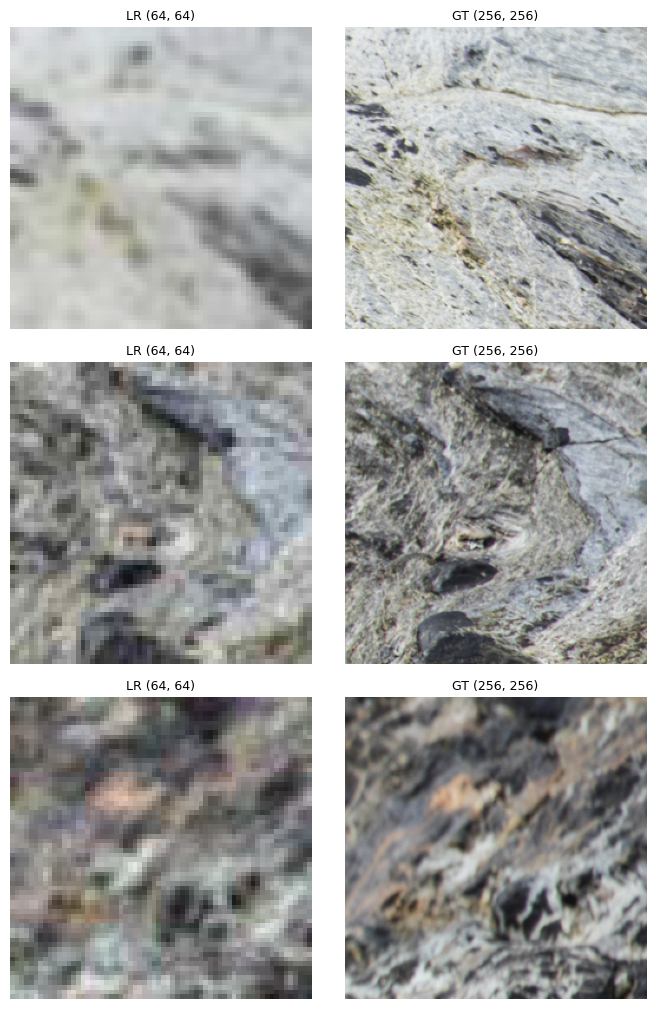

In [21]:
# Eyeball a pair: LR should look genuinely degraded (blur + noise + JPEG), not just small.
import glob
from PIL import Image
import matplotlib.pyplot as plt

names = sorted(glob.glob(f'{PAIRS}/lr/*.png'))[:3]
if not names:
    print("No pairs yet -- run make_pairs.py above.")
else:
    fig, ax = plt.subplots(len(names), 2, figsize=(7, 3.4*len(names)))
    ax = ax.reshape(len(names), 2)
    for r, lr_p in enumerate(names):
        name = lr_p.split('/')[-1]
        lr, gt = Image.open(lr_p), Image.open(f'{PAIRS}/gt/{name}')
        ax[r,0].imshow(lr); ax[r,0].set_title(f'LR {lr.size}', fontsize=9)
        ax[r,1].imshow(gt); ax[r,1].set_title(f'GT {gt.size}', fontsize=9)
        for a in ax[r]: a.axis('off')
    plt.tight_layout(); plt.show()

In [22]:
# Happy with the samples? Drop --limit and generate the full set.
# Resumable: existing pairs are skipped, so re-running after a disconnect is safe.
%cd $REPO
!python fga_integration/make_pairs.py \
  --hr_dir $SRC --out_dir $PAIRS \
  --gt_size $HR_SIZE --draws $DRAWS

/content
[pairs] 100 citra HR x 4 undian = 400 pasangan | GT 256 -> LR 64
[pairs] 100/100 citra
[pairs] selesai: 368 pasangan baru -> /content/drive/MyDrive/ifga/pairs
[pairs] lanjutkan ke cache_latents.py dengan --lr_dir /content/drive/MyDrive/ifga/pairs/lr --gt_dir /content/drive/MyDrive/ifga/pairs/gt


##### Validate the pairs before caching

In [23]:
from pathlib import Path
from PIL import Image

lr = {p.stem for p in Path(f'{PAIRS}/lr').glob('*') if p.suffix.lower() in {'.png','.jpg','.jpeg'}}
gt = {p.stem for p in Path(f'{PAIRS}/gt').glob('*') if p.suffix.lower() in {'.png','.jpg','.jpeg'}}

print(f"lr={len(lr)}  gt={len(gt)}  paired={len(lr & gt)}")
if lr - gt: print(f"LR without GT (will be skipped): {sorted(lr - gt)[:5]}")
if gt - lr: print(f"GT without LR (ignored):         {sorted(gt - lr)[:5]}")
assert lr & gt, "No matching filenames -- caching would produce nothing."

# Size uniformity decides whether --batch > 1 is even legal
sizes = {Image.open(p).size for p in Path(f'{PAIRS}/lr').glob('*.png')}
print("distinct LR sizes:", sizes if len(sizes) < 6 else f"{len(sizes)} different sizes")
print("--batch 1 REQUIRED" if len(sizes) > 1 else "uniform sizes: --batch > 1 is safe")

lr=400  gt=400  paired=400
distinct LR sizes: {(64, 64)}
uniform sizes: --batch > 1 is safe


#### Phase 3 setup — the two caching blockers

`cache_latents.py` only loads the YAML; unlike `inference_invsr.py` it never finishes the config.
Two things break as a result:

**1. Missing noise-predictor checkpoint.** `sampler_invsr.py` asserts `ckpt_path is not None`, but
`configs/sample-sd-turbo.yaml` ships `model_start.ckpt_path: ~`. `inference_invsr.py` downloads
the weights; `cache_latents.py` does not replicate that. Caching dies on the assert.

**2. Hardcoded `cache_dir`.** It points at `/mnt/sfs-common/zsyue/modelbase/...`, the original
authors' cluster path. Left alone, sd-turbo re-downloads into ephemeral storage every session.

##### And one scientific decision: `timesteps`

`cache_latents.py` defaults to `[250,200,150,100,50]` sliced to `[:num_steps]`, so `--num_steps 1`
caches at timestep **250**. But `inference_invsr.py` uses **`[200]`** for `num_steps == 1`
(and `[200,100]` for 2, against caching's `[250,200]`). Every regime disagrees.

Training on one schedule and evaluating on another is a train/test mismatch inside the *frozen*
part of the pipeline — it yields plausible-looking numbers that do not mean what you think.
The cell below pins caching to the inference schedule. Use the same value in Phase 9.

In [24]:
%cd $REPO
from huggingface_hub import hf_hub_download
from omegaconf import OmegaConf
import shutil, os

NUM_STEPS = 1
INFERENCE_TIMESTEPS = {1: [200], 2: [200, 100], 3: [200, 100, 50],
                       4: [200, 150, 100, 50], 5: [250, 200, 150, 100, 50]}

# Blocker 1 — noise predictor weights (cached on Drive)
ckpt = f'{WEIGHT}/noise_predictor_sd_turbo_v5.pth'
if not os.path.exists(ckpt):
    shutil.copy(hf_hub_download("OAOA/InvSR", "noise_predictor_sd_turbo_v5.pth"), ckpt)
    print("downloaded noise predictor ->", ckpt)
print("noise predictor:", ckpt, f"({os.path.getsize(ckpt)/1e6:.0f} MB)")

cfg = OmegaConf.load('configs/sample-sd-turbo.yaml')
cfg.model_start.ckpt_path      = ckpt              # blocker 1
cfg.sd_pipe.params.cache_dir   = MODELS            # blocker 2
cfg.timesteps                  = INFERENCE_TIMESTEPS[NUM_STEPS]   # schedule alignment
OmegaConf.save(cfg, 'configs/colab-sd-turbo.yaml')

CFG = 'configs/colab-sd-turbo.yaml'
print(f"\nwrote {CFG} | timesteps={cfg.timesteps} | num_steps={NUM_STEPS}")

/content


/usr/local/lib/python3.13/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


noise_predictor_sd_turbo_v5.pth:   0%|          | 0.00/135M [00:00<?, ?B/s]

downloaded noise predictor -> /content/drive/MyDrive/ifga/weights/noise_predictor_sd_turbo_v5.pth
noise predictor: /content/drive/MyDrive/ifga/weights/noise_predictor_sd_turbo_v5.pth (135 MB)

wrote configs/colab-sd-turbo.yaml | timesteps=[200] | num_steps=1


#### GATE 1 — Caching smoke test

Four images only. Confirms the pipeline honors `output_type="latent"`; the script raises
`RuntimeError` if the returned shape is not `(1, 4, H/8, W/8)`.

In [25]:
%cd $REPO
CACHE_DIR = f'{CACHE}/steps{NUM_STEPS}'

!python fga_integration/cache_latents.py \
  --cfg_path $CFG \
  --lr_dir $PAIRS/lr --gt_dir $PAIRS/gt \
  --out_dir $CACHE_DIR \
  --num_steps $NUM_STEPS --limit 4

/content
model_index.json: 100% 616/616 [00:00<00:00, 4.81MB/s]
Fetching 12 files:   0% 0/12 [00:00<?, ?it/s]
scheduler_config.json: 100% 553/553 [00:00<00:00, 4.84MB/s]
/usr/local/lib/python3.13/dist-packages/huggingface_hub/file_download.py:805: UserWarning: Not enough free disk space to download the file. The expected file size is: 1361.60 MB. The target location /content/drive/MyDrive/ifga/models/models--stabilityai--sd-turbo/blobs only has 1106.38 MB free disk space.
  warnings.warn(

config.json: 100% 618/618 [00:00<00:00, 4.36MB/s]

special_tokens_map.json: 100% 574/574 [00:00<00:00, 4.33MB/s]

merges.txt: 0.00B [00:00, ?B/s]

merges.txt: 525kB [00:00, 15.6MB/s]

config.json: 1.87kB [00:00, 8.89MB/s]

tokenizer_config.json: 100% 855/855 [00:00<00:00, 6.35MB/s]

Fetching 12 files:  17% 2/12 [00:00<00:01,  5.49it/s]

vocab.json: 1.06MB [00:00, 9.05MB/s]
/usr/local/lib/python3.13/dist-packages/huggingface_hub/file_download.py:805: UserWarning: Not enough free disk space to download

##### GATE 1b — latent scaling round-trip

Two minutes, and it catches a silent killer. `cache_latents.py` stores the **raw** pipeline
latent, while `train_fga.py` divides by `vae.config.scaling_factor` before decoding. If that
convention is mismatched, FGA trains to compensate for a bug rather than to add detail.

**Pass:** the rendered image is plausible. Grey noise or heavy distortion means stop and fix.

latent (1, 4, 32, 32) -> recon (1, 3, 256, 256) | scaling_factor = 0.18215


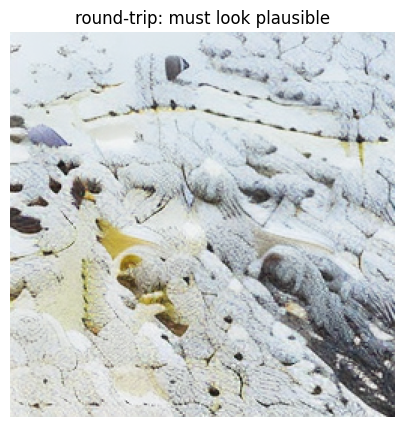

In [26]:
import numpy as np, torch
from diffusers import AutoencoderKL
from pathlib import Path
import matplotlib.pyplot as plt

vae = AutoencoderKL.from_pretrained("stabilityai/sd-turbo", subfolder="vae",
                                    cache_dir=MODELS, torch_dtype=torch.float32).cuda().eval()
p = sorted(Path(f'{CACHE_DIR}/latent').glob('*.npy'))[0]
lat = torch.from_numpy(np.load(p).astype('float32'))[None].cuda()

with torch.no_grad():
    rec = vae.decode(lat / vae.config.scaling_factor).sample

img = ((rec.clamp(-1, 1) + 1) / 2)[0].permute(1, 2, 0).cpu().numpy()
print("latent", tuple(lat.shape), "-> recon", tuple(rec.shape),
      "| scaling_factor =", vae.config.scaling_factor)
plt.figure(figsize=(5, 5)); plt.imshow(img); plt.axis('off')
plt.title('round-trip: must look plausible'); plt.show()

del vae; torch.cuda.empty_cache()

#### Phase 4 — Full cache

Safe to interrupt and resume: already-cached files are skipped. Storage is trivial (a 64x64x4
float16 latent is ~32 KB).

**This one directory is shared by both the `partial` and `full` runs.** Never regenerate it
between variants — the shared cache is part of what makes the ablation controlled.

In [ ]:
%cd $REPO
!python fga_integration/cache_latents.py \
  --cfg_path $CFG \
  --lr_dir $PAIRS/lr --gt_dir $PAIRS/gt \
  --out_dir $CACHE_DIR \
  --num_steps $NUM_STEPS

import glob
print("\ncached latents:", len(glob.glob(f'{CACHE_DIR}/latent/*.npy')))
print("cached gt:     ", len(glob.glob(f'{CACHE_DIR}/gt/*.npy')))

#### Session restore — run this after any runtime restart

`!python ... --data_dir $CACHE_DIR` expands `$CACHE_DIR` from a **Python** variable in this
kernel. After a restart (or if you jump straight to a training cell) that variable is gone,
IPython substitutes an empty string, and argparse fails with
`argument --data_dir: expected one argument`. Same for `$AMP`, `$ITERS`, `$ACCUM`, `$EXP`.

This cell rebuilds every variable the `!` cells reference, without re-running install or
caching. Safe to run at any point; it re-derives, never overwrites work on Drive.

In [ ]:
# --- session restore: redefine everything the ! cells interpolate ---
import os, sys, torch, importlib

REPO = "/content/IFGA-SR"
SRC  = f"{REPO}/src"
assert os.path.exists(f"{REPO}/.git"), "repo missing -- run the Phase 0 clone cell first"
os.chdir(REPO)

# import paths (kernel + subprocesses)
for p in (SRC, REPO):
    if p not in sys.path:
        sys.path.insert(0, p)
os.environ["PYTHONPATH"] = REPO + os.pathsep + SRC + os.pathsep + os.environ.get("PYTHONPATH", "")
importlib.invalidate_caches()

# Drive layout
if not os.path.ismount('/content/drive'):
    from google.colab import drive
    drive.mount('/content/drive')

BASE   = '/content/drive/MyDrive/ifga'
CACHE  = f'{BASE}/cache'
EXP    = f'{BASE}/experiments'
WEIGHT = f'{BASE}/weights'
MODELS = f'{BASE}/models'
PAIRS  = f'{BASE}/pairs'
os.environ['HF_HOME']      = MODELS
os.environ['HF_HUB_CACHE'] = f'{MODELS}/hub'

# caching / training knobs
NUM_STEPS = 1
CACHE_DIR = f'{CACHE}/steps{NUM_STEPS}'
CFG       = 'configs/colab-sd-turbo.yaml'
HR_SIZE, DRAWS = 256, 4

AMP = "bf16" if torch.cuda.get_device_capability(0)[0] >= 8 else "fp16"
ITERS, ACCUM = 10000, 4      # <-- keep in sync with the projection cell

# fail loudly here rather than inside argparse
import glob
n_lat = len(glob.glob(f'{CACHE_DIR}/latent/*.npy'))
n_gt  = len(glob.glob(f'{CACHE_DIR}/gt/*.npy'))
assert n_lat > 0, f"no cached latents in {CACHE_DIR} -- re-run the Phase 4 cache cell"

for k in ("REPO", "CACHE_DIR", "EXP", "AMP", "ITERS", "ACCUM"):
    print(f"{k:10s} = {globals()[k]}")
print(f"cached      : {n_lat} latents / {n_gt} gt")

#### GATE 2 — Training smoke test

50 iterations, both modes. Four things to confirm before committing to a real run.

In [ ]:
%cd $REPO
!python fga_integration/train_fga.py \
  --data_dir $CACHE_DIR --mode partial \
  --iters 50 --batch 1 --accum 2 \
  --log_every 5 --val_every 25 \
  --amp $AMP --seed 123456 \
  --out_dir /content/smoke_partial

/content
config.json: 100% 655/655 [00:00<00:00, 3.94MB/s]
vae/diffusion_pytorch_model.safetensors: 100% 335M/335M [00:45<00:00, 7.34MB/s]
/usr/local/lib/python3.13/dist-packages/torch/functional.py:505: UserWarning: torch.meshgrid: in an upcoming release, it will be required to pass the indexing argument. (Triggered internally at /pytorch/aten/src/ATen/native/TensorShape.cpp:4381.)
  return _VF.meshgrid(tensors, **kwargs)  # type: ignore[attr-defined]
[model] mode=partial | parameter dilatih = 595,876 (0.707% dari VAE)
[model] vae.config.scaling_factor = 0.18215
[data] train=3 | val=1
/content/IFGA-SR/fga_integration/train_fga.py:210: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  scaler = torch.cuda.amp.GradScaler(enabled=(args.amp == "fp16"))


In [ ]:
%cd $REPO
!python fga_integration/train_fga.py \
  --data_dir $CACHE_DIR --mode full \
  --iters 50 --batch 1 --accum 2 \
  --log_every 5 --val_every 25 \
  --amp $AMP --seed 123456 \
  --out_dir /content/smoke_full

##### GATE 2 pass criteria

1. **`parameter dilatih` is non-zero.** If `0`, `inject_fga` found no upsamplers and nothing trains.
2. **`full` param count strictly greater than `partial`.** If equal, mode selection is broken and
   your two conditions are secretly identical — the H3 ablation would be meaningless.
3. **Step-0 loss equals baseline reconstruction loss.** A consequence of the zero-init `unembed`:
   at iteration 0 the output is bit-identical to baseline InvSR. A large or diverging initial loss
   means zero-init is not taking effect and the residual branch is corrupting the pretrained prior.
4. **Loss is finite.** On a T4 with `fp16`, nan means falling back to `--amp off` (not `bf16`).

Record both parameter counts — they belong in your results table.

In [ ]:
# Extrapolate the real cost, then decide --iters. Read minutes from the smoke-test log above.
MINUTES_ELAPSED = 1.0     # <-- EDIT: the "[selesai] N menit" figure from the partial run
MICRO_DONE      = 50 * 2  # --iters 50 x --accum 2

per_micro = MINUTES_ELAPSED / MICRO_DONE
for iters, accum in [(20000, 8), (10000, 4), (5000, 4), (2000, 4)]:
    hrs = per_micro * iters * accum / 60
    fit = "OK" if hrs < 8 else ("tight" if hrs < 11 else "WILL NOT FINISH")
    print(f"--iters {iters:>5} --accum {accum}: {hrs:6.1f} h   {fit}")

for line in [
    "",
    "Colab caps sessions at ~12h (free tier disconnects sooner), and train_fga.py has NO",
    "resume: the loop is a bare `for step in range(args.iters)` and save_fga persists only",
    ".fga. weights -- no optimizer, scaler, or LR-scheduler state. A disconnect at hour 11",
    "costs the entire run.",
    "",
    "Size the run to finish inside one session, and apply the SAME values to both variants.",
    "Other levers: --inner_dim 32 (about halves FGA compute), or smaller HR crops (re-cache).",
]:
    print(line)

In [ ]:
!rm -rf /content/smoke_partial /content/smoke_full
print("smoke artifacts removed")

#### Phase 6 — Train `partial`

Set `ITERS` / `ACCUM` from the projection above. Output goes to Drive so partial progress
survives a disconnect.

In [ ]:
ITERS, ACCUM = 10000, 4      # <-- set from the projection cell
print(f"iters={ITERS} accum={ACCUM} -> {ITERS*ACCUM:,} micro-steps | amp={AMP}")

In [ ]:
%cd $REPO
!python fga_integration/train_fga.py \
  --data_dir $CACHE_DIR --mode partial \
  --iters $ITERS --batch 1 --accum $ACCUM \
  --lr 1e-4 --amp $AMP --seed 123456 \
  --w_pixel 1.0 --w_freq 0.1 --freq_mode full \
  --val_every 500 --save_every 500 --log_every 50 \
  --out_dir $EXP/fga_partial

##### What healthy training looks like

- Total loss falls from the baseline value; the frequency term should drop *alongside* pixel loss,
  not trade off against it.
- Validation PSNR improves over baseline, then plateaus.
- `spec` (spectral consistency, 1.0 = perfect) trends up.

If validation PSNR sits **exactly** at baseline for thousands of steps, FGA is learning to output
zero — the residual branch is finding no usable signal. Check the LR and confirm gradients are
reaching FGA parameters.

#### Phase 7 — Train `full`

Identical command, two changes only: `--mode` and `--out_dir`.

**Controlled-comparison requirement.** `--data_dir`, `--iters`, `--batch`, `--accum`, `--lr`,
`--seed`, `--amp`, and every loss weight must be byte-identical to Phase 6. If any one differs,
the partial-vs-full comparison is confounded and no H3 conclusion follows from it.

In [ ]:
%cd $REPO
!python fga_integration/train_fga.py \
  --data_dir $CACHE_DIR --mode full \
  --iters $ITERS --batch 1 --accum $ACCUM \
  --lr 1e-4 --amp $AMP --seed 123456 \
  --w_pixel 1.0 --w_freq 0.1 --freq_mode full \
  --val_every 500 --save_every 500 --log_every 50 \
  --out_dir $EXP/fga_full

##### Verify the ablation was actually controlled

In [ ]:
import json
a = json.load(open(f'{EXP}/fga_partial/config.json'))
b = json.load(open(f'{EXP}/fga_full/config.json'))

diff = {k: (a.get(k), b.get(k)) for k in set(a) | set(b) if a.get(k) != b.get(k)}
print("differing keys:", json.dumps(diff, indent=2))

allowed = {'mode', 'out_dir'}
extra = set(diff) - allowed
if extra:
    print(f"\nCONFOUNDED: unexpected differences in {extra} -- the H3 comparison is not valid.")
else:
    print("\nOK: only mode and out_dir differ. Comparison is controlled.")

##### Results

```
{EXP}/fga_partial/
├── config.json           argparse snapshot -- archive with the checkpoint
├── history.json          per-step train + val log
├── fga_partial_best.pth  best val PSNR  <-- use for evaluation
├── fga_partial_last.pth
└── fga_partial_final.pth
```

Checkpoints hold only `.fga.` keys, so ~1-2 MB each.

In [ ]:
import json, glob, os
for mode in ('partial', 'full'):
    d = f'{EXP}/fga_{mode}'
    if not os.path.exists(f'{d}/history.json'):
        print(f"{mode}: not trained yet"); continue
    h = json.load(open(f'{d}/history.json'))
    vals = [e['val']['psnr'] for e in h if 'val' in e]
    print(f"{mode:8} | val entries={len(vals)} | best PSNR={max(vals):.3f} dB" if vals
          else f"{mode:8} | no validation entries yet")
    for f in sorted(glob.glob(f'{d}/*.pth')):
        print(f"           {os.path.basename(f):28} {os.path.getsize(f)/1e6:.2f} MB")

#### Phase 8 — Inference wiring

`sampler_invsr.py` on GitHub `master` calls `inject_fga(...)` but **never reads `fga_ckpt`**.
Because `unembed` is zero-initialised, `delta == 0`, so `partial` and `full` inference would come
out *bit-identical to baseline* and the whole experiment would silently read as a null result.

The fix is applied locally in this repo but is **not committed to `master`**, so the cell below
re-applies it idempotently to the Colab clone — same pattern as the Phase 0 unblock cell.

It adds two things:
- `sampler_invsr.py`: load the checkpoint, with asserts on `mode`, on `unexpected` keys, and on
  any `.fga.` key left unpopulated. `inner_dim` is taken **from the checkpoint**, not the default.
- `inference_invsr.py`: `--fga_mode` / `--fga_ckpt` flags that override the YAML, so one config
  serves the baseline and both variants.

In [ ]:
%cd $REPO
# --- Phase 8a: make inference actually load the trained FGA weights ---
from pathlib import Path

SAMPLER_OLD = '        inject_fga(sd_pipe.vae, mode=self.configs.get("fga_mode", "none"))\n'
SAMPLER_NEW = '''        fga_mode = self.configs.get("fga_mode", "none")
        if fga_mode == "none":
            inject_fga(sd_pipe.vae, mode="none")
        else:
            fga_ckpt = self.configs.get("fga_ckpt", None)
            assert fga_ckpt is not None, (
                f"fga_mode={fga_mode} but fga_ckpt is not set. Without the trained weights "
                "the zero-initialised unembed makes output bit-identical to baseline."
            )
            ckpt = torch.load(fga_ckpt, map_location="cuda")
            assert ckpt["mode"] == fga_mode, (
                f"Checkpoint mode={ckpt[\'mode\']} does not match config fga_mode={fga_mode}"
            )
            inject_fga(sd_pipe.vae, mode=fga_mode, inner_dim=ckpt.get("inner_dim", 64))
            missing, unexpected = sd_pipe.vae.load_state_dict(ckpt["state_dict"], strict=False)
            assert not unexpected, f"Unexpected keys in FGA checkpoint: {unexpected}"
            still_missing = [k for k in missing if ".fga." in k]
            assert not still_missing, f"FGA keys not populated: {still_missing[:5]}"
            self.write_log(
                f"Loaded FGA weights ({fga_mode}, inner_dim={ckpt.get(\'inner_dim\', 64)}, "
                f"step={ckpt.get(\'step\')}) from {fga_ckpt}"
            )
'''

s = Path("sampler_invsr.py").read_text()
if "fga_ckpt" in s:
    print("8a: sampler_invsr.py already patched")
else:
    assert s.count(SAMPLER_OLD) == 1, "inject_fga call not found -- upstream changed?"
    Path("sampler_invsr.py").write_text(s.replace(SAMPLER_OLD, SAMPLER_NEW))
    print("8a: sampler_invsr.py patched")

INF_OLD = '''    args = parser.parse_args()
'''
INF_NEW = '''    parser.add_argument(
        "--fga_mode", type=str, default="", choices=["none", "partial", "full"],
        help="FGA injection mode. Overrides fga_mode in the config.",
    )
    parser.add_argument(
        "--fga_ckpt", type=str, default="", help="Trained FGA checkpoint (.pth)",
    )
    args = parser.parse_args()
'''
CFG_OLD = "    configs.bs = args.bs\n"
CFG_NEW = '''    if args.fga_mode:
        configs.fga_mode = args.fga_mode
    if args.fga_ckpt:
        configs.fga_ckpt = args.fga_ckpt

    configs.bs = args.bs
'''

s = Path("inference_invsr.py").read_text()
if "--fga_mode" in s:
    print("8b: inference_invsr.py already patched")
else:
    assert s.count(INF_OLD) == 1 and s.count(CFG_OLD) == 1
    Path("inference_invsr.py").write_text(s.replace(INF_OLD, INF_NEW).replace(CFG_OLD, CFG_NEW))
    print("8b: inference_invsr.py patched")

!python -c "import ast; ast.parse(open('sampler_invsr.py').read()); ast.parse(open('inference_invsr.py').read()); print('both files parse')"

##### Build the evaluation set from the **val split**

`LatentHRDataset` holds out the first `val_size` names (sorted) as validation, and FGA never saw
them during training. Reporting numbers on the training pairs would be meaningless, so this cell
reconstructs the exact same split and copies those LR/GT images into `/content/eval`.

The split rule is copied verbatim from `train_fga.py`: `val_size = min(32, max(1, len(names)//10))`.
If you trained with a non-default `--val_size`, change `VAL_SIZE` below to match.

In [ ]:
import shutil, json
from pathlib import Path

VAL_SIZE = 32      # must equal the --val_size used in training (default 32)

names = sorted(p.stem for p in Path(f'{CACHE_DIR}/latent').glob('*.npy'))
assert names, f"no cache at {CACHE_DIR} -- run the session-restore cell"
val_size  = min(VAL_SIZE, max(1, len(names) // 10))
val_names = names[:val_size]

EVAL = '/content/eval'
for sub in ('lr', 'gt'):
    d = Path(EVAL) / sub
    if d.exists():
        shutil.rmtree(d)
    d.mkdir(parents=True)
    for n in val_names:
        shutil.copy(f'{PAIRS}/{sub}/{n}.png', d / f'{n}.png')

print(f"total cached = {len(names)} | val split = {val_size}")
print(f"eval set -> {EVAL}/lr  ({len(list(Path(EVAL, 'lr').glob('*.png')))} images)")
print("first few:", val_names[:3])

##### Run all three conditions

Identical command three times; only `--fga_mode` / `--fga_ckpt` / output dir change. `-n 1` must
match the `--num_steps` you cached and trained at — a different schedule means evaluating the
frozen backbone in a regime it never produced latents for.

`*_best.pth` is the checkpoint selected on val PSNR; `_last` and `_final` are just wherever the
loop happened to stop.

In [ ]:
%cd $REPO
# 1/3 — baseline (no FGA). This is the number everything else is measured against.
!python inference_invsr.py -i /content/eval/lr -o /content/out_baseline \
  --cfg_path $CFG -n $NUM_STEPS --fga_mode none

In [ ]:
%cd $REPO
# 2/3 — partial
!python inference_invsr.py -i /content/eval/lr -o /content/out_partial \
  --cfg_path $CFG -n $NUM_STEPS \
  --fga_mode partial --fga_ckpt $EXP/fga_partial/fga_partial_best.pth

In [ ]:
%cd $REPO
# 3/3 — full
!python inference_invsr.py -i /content/eval/lr -o /content/out_full \
  --cfg_path $CFG -n $NUM_STEPS \
  --fga_mode full --fga_ckpt $EXP/fga_full/fga_full_best.pth

##### GATE 3 — the output must actually differ from baseline

The single most important check in the whole notebook. If `mean abs diff` is exactly `0.0`, the
FGA weights did not reach the model and **every downstream metric is a duplicate of the
baseline** — a result that looks like "FGA makes no difference" but is really a wiring bug.

The asserts added in Phase 8a should make a silent failure impossible, but verify end-to-end
anyway: a non-zero diff is proof the residual branch is contributing.

In [ ]:
import numpy as np, glob, os
from PIL import Image

def load(d, name):
    return np.asarray(Image.open(os.path.join(d, name))).astype(np.float64)

base = sorted(os.path.basename(p) for p in glob.glob('/content/out_baseline/*.png'))
assert base, "baseline produced no images"

for variant in ('partial', 'full'):
    d = f'/content/out_{variant}'
    diffs = [np.abs(load(d, n) - load('/content/out_baseline', n)).mean()
             for n in base if os.path.exists(os.path.join(d, n))]
    if not diffs:
        print(f"{variant:8} | NOT RUN"); continue
    m = float(np.mean(diffs))
    verdict = "FAIL -- identical to baseline, checkpoint did not load" if m == 0.0 else "OK"
    print(f"{variant:8} | mean abs diff vs baseline = {m:.4f} (0-255 scale) | {verdict}")

# partial vs full must differ too, or the two conditions are secretly the same model
if os.path.exists('/content/out_full') and os.path.exists('/content/out_partial'):
    pf = [np.abs(load('/content/out_full', n) - load('/content/out_partial', n)).mean()
          for n in base if os.path.exists(f'/content/out_full/{n}')]
    if pf:
        print(f"partial vs full  = {np.mean(pf):.4f}  "
              f"({'OK' if np.mean(pf) > 0 else 'FAIL -- H3 ablation is degenerate'})")

#### Phase 9 — Metrics

Reference metrics against the held-out GT. Run the same command for all three output dirs so the
comparison is apples-to-apples; `--log_name` keeps the three logs separate.

PSNR/SSIM reward pixel fidelity and tend to *punish* the high-frequency detail FGA is designed to
add, so report LPIPS alongside them rather than PSNR alone — a small PSNR drop with a clear LPIPS
gain is the expected signature of a working frequency-aware module, not a regression.

In [ ]:
import os, subprocess
os.chdir(REPO)

for name in ('baseline', 'partial', 'full'):
    d = f'/content/out_{name}'
    if not os.path.exists(d):
        print(f"{name}: not run yet")
        continue
    print(f"\n===== {name} =====")
    # subprocess, not !magic: a failing metric script must raise here rather than
    # scroll past and leave you comparing three logs when only two were written.
    r = subprocess.run([
        "python", "scripts/cal_metrics_ref.py",
        "--gt_dir", "/content/eval/gt",
        "--sr_dir", d,
        "--log_name", f"/content/metrics_{name}.log",
    ])
    assert r.returncode == 0, f"metrics failed for {name} (exit {r.returncode})"

##### Precision caveat (runbook Phase 8d)

If your eval config enables `vae_fp16`, `inject_fga` casts FGA to fp16 to match the wrapped
upsampler — but FGA is **trained in float32**, because its softmax attention and LayerNorm are
unstable at half precision. The `colab-sd-turbo.yaml` written in Phase 3 has no `vae_fp16` key, so
the default path here is fp32 and you are fine. Do not add one for reported runs without
measuring the degradation and stating it.

##### Archive with every reported number

`config.json` + `history.json` + the `.pth`, plus the parameter counts from GATE 2 and the
`mean abs diff` from GATE 3. Those five artefacts are what make the result reproducible.